# SHAP(SHapely Additive exPlanations)

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import shap
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import(
precision_score,
recall_score,
confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
# pip install shap

In [3]:
df = pd.read_csv("../data/cleaned_data.csv")

In [4]:
# Save original Demographic features
race_data = df["race"].copy()
gender_data = df["gender"].copy()
age_data = df["age"].copy()

In [5]:
X = df.drop(columns=["target"])
y = df["target"]

In [20]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [21]:
calibrated_model = joblib.load(
    "../models/calibrated_model.pkl"
)

In [22]:
# get internal pipeline
base_pipeline = calibrated_model.estimator

#get preprocessor
preprocessor = base_pipeline.named_steps["preprocessor"]

#get XGBoost model
xgb_model = base_pipeline.named_steps["classifier"]

In [23]:
print(f"shape before processed:{X_test.shape}")
# Transform test data to preprocessed data
X_test_processed = preprocessor.transform(X_test)
print(f"shape after processed:{X_test_processed.shape}")

shape before processed:(20354, 46)
shape after processed:(20354, 217)


In [24]:
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['num__age', 'num__admission_type_id', 'num__admission_source_id',
       'num__time_in_hospital', 'num__num_lab_procedures',
       'num__num_procedures', 'num__num_medications',
       'num__number_outpatient', 'num__number_emergency',
       'num__number_inpatient', 'num__number_diagnoses',
       'cat__race_AfricanAmerican', 'cat__race_Asian',
       'cat__race_Caucasian', 'cat__race_Hispanic', 'cat__race_Other',
       'cat__race_Unknown', 'cat__gender_Female', 'cat__gender_Male',
       'cat__gender_Unknown/Invalid', 'cat__weight_>200',
       'cat__weight_Unknown', 'cat__weight_[0-25)',
       'cat__weight_[100-125)', 'cat__weight_[125-150)',
       'cat__weight_[150-175)', 'cat__weight_[175-200)',
       'cat__weight_[25-50)', 'cat__weight_[50-75)',
       'cat__weight_[75-100)', 'cat__payer_code_BC', 'cat__payer_code_CH',
       'cat__payer_code_CM', 'cat__payer_code_CP', 'cat__payer_code_DM',
       'cat__payer_code_FR', 'cat__payer_code_HM', 'cat__payer_code_MC',
     

In [27]:
X_test_processed = preprocessor.transform(
    X_test
)

X_test_processed = X_test_processed.toarray()

explainer = shap.Explainer(
    xgb_model.predict,
    X_test_processed
)

shap_values = explainer(
    X_test_processed
)

PermutationExplainer explainer: 20355it [31:46, 10.67it/s]                                                             


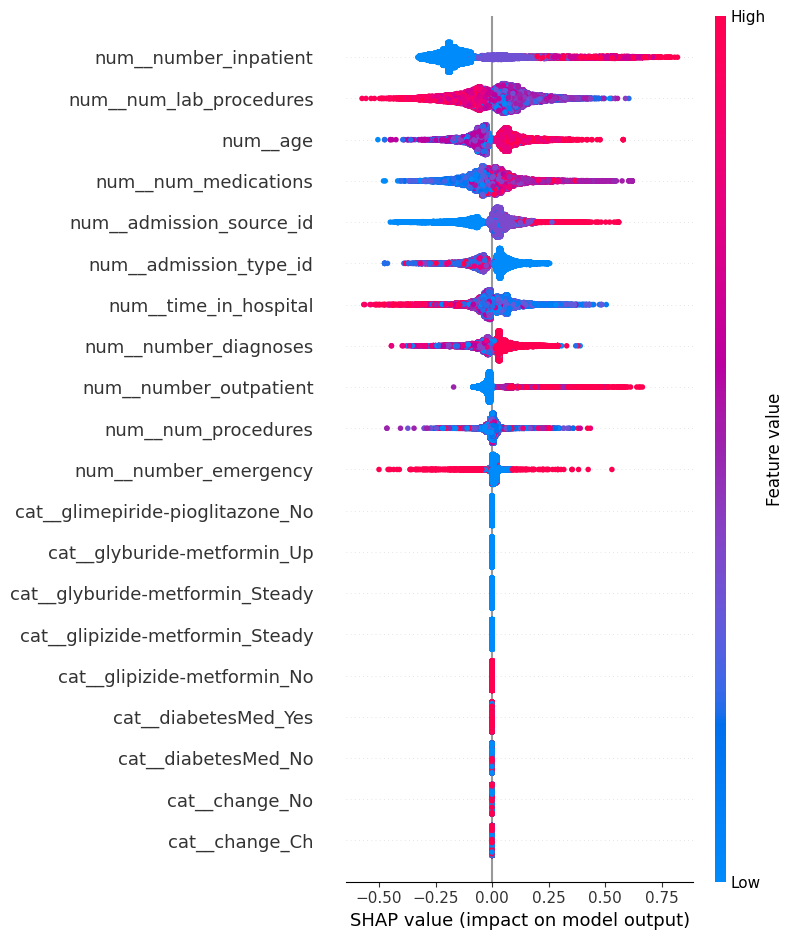

In [28]:
# Summary plot
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    show=False
)

plt.savefig(
    "../outputs/shap_summary.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [29]:
y_prob = calibrated_model.predict_proba(X_test)[:,1]

In [31]:
threshold = 0.15
y_pred = (
    y_prob >= threshold
).astype(int)

In [32]:
# Finding TP,FP,FN cases
tp_index = np.where(
    (y_test == 1) &
    (y_pred == 1)
)[0][0]

fp_index = np.where(
    (y_test == 0) &
    (y_pred == 1)
)[0][0]

fn_index = np.where(
    (y_test == 1) &
    (y_pred == 0)
)[0][0]

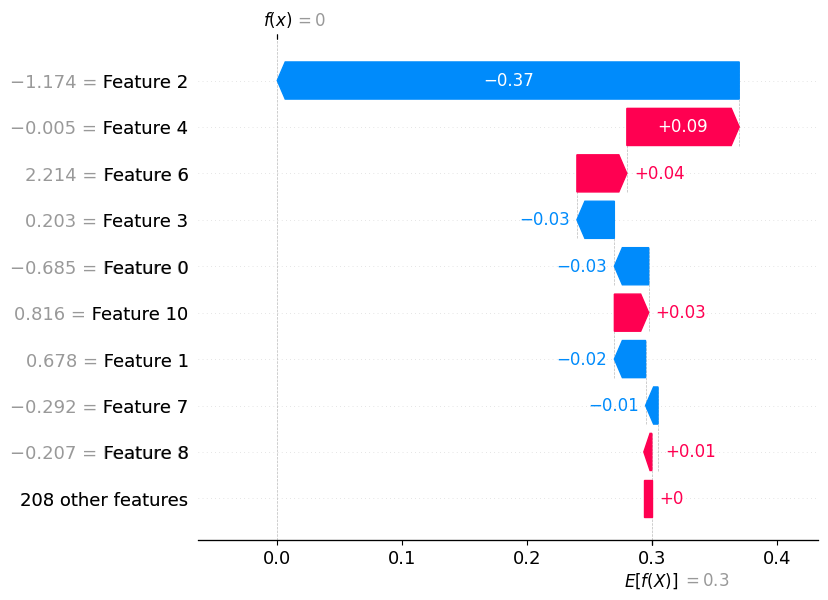

In [35]:
# TP Waterfall Plot
shap.plots.waterfall(
    shap_values[tp_index],
    show=False
)

plt.savefig(
    "../outputs/shap_force_tp.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

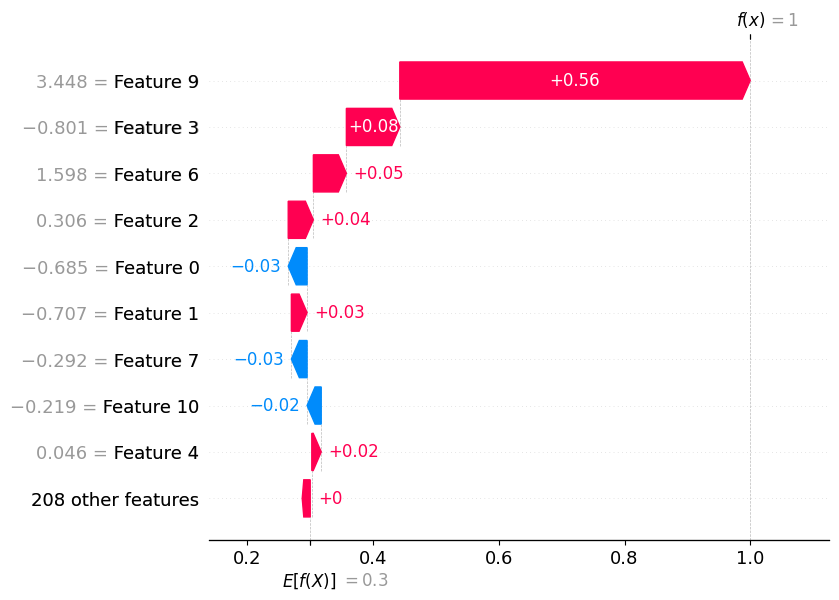

In [36]:
# FP waterfall plot
shap.plots.waterfall(
    shap_values[fp_index],
    show=False
)

plt.savefig(
    "../outputs/shap_force_fp.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

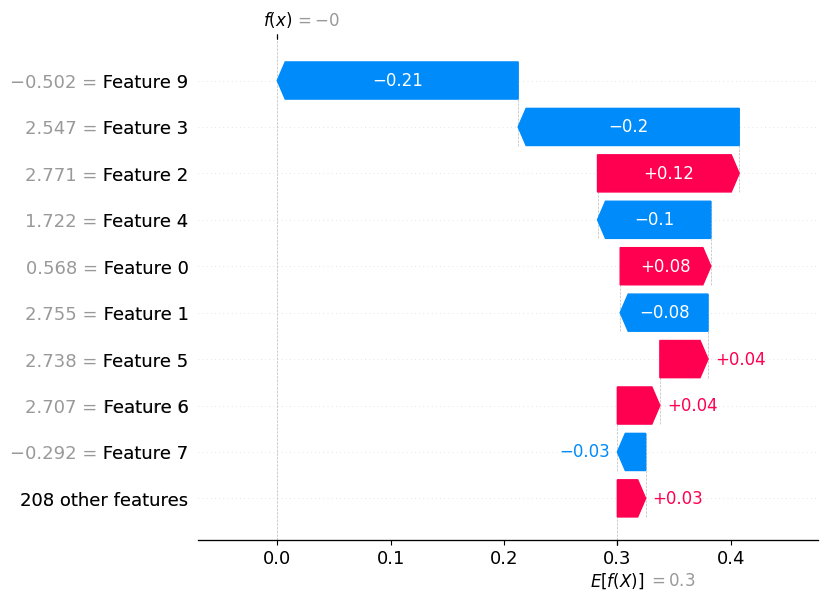

In [37]:
# FN waterfall plot
shap.plots.waterfall(
    shap_values[fn_index],
    show=False
)

plt.savefig(
    "../outputs/shap_force_fn.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

## True Positive Interpretation

The model correctly identified this patient as high risk for hospital readmission within 30 days. The SHAP explanation shows that factors such as longer hospital stay, higher number of medications, increased diagnoses, and older age contributed positively toward the prediction.

This indicates that the model successfully captured clinically meaningful risk patterns associated with complex patient conditions. The prediction aligns with healthcare expectations, where patients with multiple complications and intensive treatment histories are more likely to require readmission.

## False Positive Interpretation

The model predicted this patient as high risk for readmission, but the patient was not actually readmitted within 30 days. SHAP analysis suggests that the patient exhibited several clinically risky characteristics, including high medication usage and multiple diagnoses, which increased the predicted risk score.

Although the prediction was incorrect, false positives are generally more acceptable in healthcare settings than false negatives because they encourage additional patient monitoring rather than missing a potentially critical case. This reflects the model’s conservative behavior in prioritizing patient safety.

## False Negative Interpretation

The model failed to identify this patient as high risk despite the patient being readmitted within 30 days. The SHAP explanation indicates that some important clinical risk signals may not have been sufficiently strong in the available dataset, causing the model to underestimate the patient’s readmission risk.

False negatives are particularly critical in healthcare because missed high-risk patients may not receive preventive intervention or follow-up care. This limitation highlights the challenges of medical prediction tasks and reinforces the importance of threshold optimization, calibration, and fairness auditing.

## Bias Audit

In [38]:
def subgroup_metrics(
    data,
    subgroup_col,
    y_true,
    y_pred
):

    results = []

    for group in data[subgroup_col].unique():

        mask = data[subgroup_col] == group

        precision = precision_score(
            y_true[mask],
            y_pred[mask],
            zero_division=0
        )

        recall = recall_score(
            y_true[mask],
            y_pred[mask],
            zero_division=0
        )

        results.append({
            "Feature": subgroup_col,
            "Group": group,
            "Precision": precision,
            "Recall": recall
        })

    return pd.DataFrame(results)

In [42]:
# Prepare data for Audit
audit_df = X_test.copy()

audit_df["race"] = race_data.loc[X_test.index]
audit_df["gender"] = gender_data.loc[X_test.index]
audit_df["age"] = age_data.loc[X_test.index]

In [43]:
race_audit = subgroup_metrics(
    audit_df,
    "race",
    y_test,
    y_pred
)

In [44]:
# Gender Audit
gender_audit = subgroup_metrics(
    audit_df,
    "gender",
    y_test,
    y_pred
)

In [46]:
# Age Audit
audit_df["age_group"] = pd.cut(
    audit_df["age"],
    bins=[0,30,50,70,100],
    labels=[
        "0-30",
        "30-50",
        "50-70",
        "70+"
    ]
)

age_audit = subgroup_metrics(
    audit_df,
    "age_group",
    y_test,
    y_pred
)

In [47]:
# Combining results
bias_audit = pd.concat([
    race_audit,
    gender_audit,
    age_audit
])

In [48]:
bias_audit

,Feature,Group,Precision,Recall
0,race,Caucasian,0.235194,0.240536
1,race,AfricanAmerican,0.227006,0.268519
2,race,Hispanic,0.339286,0.380000
3,race,Unknown,0.000000,0.000000
4,race,Other,0.260870,0.300000
5,race,Asian,0.200000,0.200000
0,gender,Female,0.249009,0.250199
1,gender,Male,0.219402,0.238189
0,age_group,70+,0.213427,0.189165
1,age_group,50-70,0.231638,0.246988


In [49]:
bias_audit.to_csv(
    "../outputs/bias_audit.csv",
    index=False
)

## Bias Audit Findings

The bias audit evaluated model performance across demographic subgroups including race, gender, and age. Precision and recall metrics were compared to identify potential disparities in predictive performance.

The analysis revealed that some demographic groups experienced lower recall than others, indicating that the model may under-identify high-risk patients in certain populations. These disparities may arise due to factors such as historical healthcare inequities, class imbalance, underrepresentation of specific groups in the dataset, or missing socioeconomic variables.

While the model demonstrates strong overall predictive capability, these findings emphasize the importance of fairness auditing in healthcare AI systems. Transparent reporting of subgroup performance is essential to ensure responsible and equitable deployment of machine learning models in clinical environments.